In [1]:
import numpy as np

In [2]:
name = "AFUGIS"
cell = np.load(f"{name}/Cell_{name}.cell", allow_pickle=True)

In [3]:
cell

------------- Cell2mol CELL Object ----------------
 Version               = 0.1
 Type                  = cell
 Name (Refcode)        = AFUGIS
 Num Atoms             = 230
 Cell Parameters a:c   = [10.878, 12.781, 15.368]
 Cell Parameters al:ga = [98.705, 99.605, 107.216]
 # Molecules:          = 2
 With Formulae:                               
    0: H68-C42-N4-Fe 
    1: H68-C42-N4-Fe 
---------------------------------------------------
 # of Ref Molecules:   = 1
 With Formulae:                                  
    0: H68-C42-N4-Fe 

In [4]:
cell.refmoleclist

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 115
  Formula                      = H68-C42-N4-Fe
  Has Adjacency Matrix         = YES
  Number of Ligands            = 2
  Number of Metals             = 1
 ---------------------------------------------------]

In [5]:
for ref in cell.refmoleclist:
    if ref.iscomplex:
        print(f"{ref.subtype}({ref.type}) {ref.formula} {ref.is_haptic}")
        for lig in ref.ligands:
            print(f"|- {lig.subtype}({lig.type}) {lig.formula} {lig.is_haptic} {lig.denticity}")
            # print(lig.groups)
            for group in lig.groups:
                print(f"|= {group.subtype} ({group.type}) {group.formula} {group.is_haptic} {group.denticity} {group.closest_metal.label}")
            print("")
        for metal in ref.metals:
            print(f"|# {metal.subtype}({metal.type}) {metal.label} {metal.coord_nr} {metal.coord_geometry}")
            print(f"|# {metal.get_coord_sphere_formula()}")
    else:
        print(f"{ref.subtype}({ref.type}) {ref.formula}")
    print("")

molecule(specie) H68-C42-N4-Fe False
|- ligand(specie) H15-C7-N2 False 2
|= group (specie) N False 1 Fe
|= group (specie) N False 1 Fe

|- ligand(specie) H53-C35-N2 False 2
|= group (specie) N False 1 Fe
|= group (specie) N False 1 Fe

|# metal(atom) Fe 4 Seesaw
|# N4



In [12]:
for idx, mol in enumerate(cell.moleclist):
    if mol.iscomplex:
        print(f"{idx}: {mol.subtype}({mol.type}) {mol.formula} {mol.is_haptic} {mol.totcharge} {mol.spin}") #\n   {mol.adjnum=}\n   {mol.madjnum=} \n   {mol.smiles=}")
        print(mol.adjnum)
        for lig in mol.ligands:
            print(f"|- {lig.subtype}({lig.type}) {lig.formula} {lig.is_haptic} {lig.denticity} {lig.totcharge}")# \n   {lig.smiles=}")
            print(f"|- {lig.connected_idx}")
            # print(lig.groups)
            for group in lig.groups:
                print(f"|-- {group.subtype} ({group.type}) {group.formula} {group.is_haptic} {group.denticity} {group.closest_metal.label}")
                for met in group.metals:
                    print(f"|--- {met.label} {met.mconnec}")
            print("")
        for metal in mol.metals:
            print(f"|# {metal.subtype}({metal.type}) {metal.label} {metal.coord_nr} {metal.coord_geometry} {metal.charge} {metal.spin} {metal.coord_sphere_formula} {metal.connec} {metal.mconnec}")
            print(f"|# {metal.get_coord_sphere_formula()}")
            print(f"|# {metal.coord_sphere_formula}")
            print(f"|# {metal.mconnec=} {metal.connec=}")
            print(metal.metal_adjacency)
            # for bond in metal.bonds:
                # print(f"|--- {bond}")
            
    else:
        print(f"{idx}: {mol.subtype}({mol.type}) {mol.formula} {mol.totcharge} {mol.spin}\n  {mol.smiles}")
    print("")

0: molecule(specie) H68-C42-N4-Fe False 0 5
[5 3 3 4 1 4 1 4 1 1 1 4 1 1 1 3 1 4 1 1 1 4 1 1 1 3 3 4 3 4 1 3 3 4 1 1 1
 4 1 1 1 4 1 1 1 3 1 1 1 4 1 1 1 4 1 1 1 3 4 4 1 3 1 3 1 3 4 1 4 1 1 1 4 1
 1 1 3 1 3 1 1 1 4 1 1 1 3 3 3 1 4 1 3 1 4 4 1 4 1 1 1 4 1 1 1 3 1 4 1 1 1
 4 1 1 1]
|- ligand(specie) H53-C35-N2 False 2 -1
|- [0, 1]
|-- group (specie) N False 1 Fe
|--- Fe 5
|-- group (specie) N False 1 Fe
|--- Fe 5

|- ligand(specie) H15-C7-N2 False 2 -1
|- [0, 1]
|-- group (specie) N False 1 Fe
|--- Fe 5
|-- group (specie) N False 1 Fe
|--- Fe 5

|# metal(atom) Fe 4 Seesaw 2.0 5 N4 5 5
|# N4
|# N4
|# metal.mconnec=5 metal.connec=5
[1, 2, 25, 26, 105]

1: molecule(specie) H68-C42-N4-Fe False 0 5
[5 3 3 3 1 4 1 4 1 1 1 4 1 1 1 4 1 4 1 1 1 4 1 1 1 3 3 4 3 3 1 3 4 4 1 1 1
 4 1 1 1 4 1 1 1 4 1 1 1 4 1 1 1 4 1 1 1 3 3 3 1 3 1 3 1 3 4 1 4 1 1 1 4 1
 1 1 4 1 4 1 1 1 4 1 1 1 3 3 3 1 3 1 3 1 3 4 1 4 1 1 1 4 1 1 1 4 1 4 1 1 1
 4 1 1 1]
|- ligand(specie) H15-C7-N2 False 2 -1
|- [0, 1]
|-- group (specie

In [7]:
for idx, mol in enumerate(cell.moleclist):
    if mol.iscomplex:
        for metal in mol.metals:
            for bond in metal.bonds:
                print(f"{bond.atom1.label}-{bond.atom2.label} {bond.order}")
        print("")

Fe-N 0
Fe-N 0
Fe-N 0
Fe-N 0
Fe-C 0

Fe-N 0
Fe-N 0
Fe-C 0
Fe-N 0
Fe-N 0



In [13]:
from cell2mol.charge_assignment import get_smiles_complex
from rdkit import Chem

smiles='[H]C1=C(C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])[N-](c2c(C([H])(C([H])([H])[H])C([H])([H])[H])c([H])c([H])c([H])c2C([H])(C([H])([H])[H])C([H])([H])[H])~[Fe+2]23(~N(c4c(C([H])(C([H])([H])[H])C([H])([H])[H])c([H])c([H])c([H])c4C([H])(C([H])([H])[H])C([H])([H])[H])=C1C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])~N(C([H])(C([H])([H])[H])C([H])([H])[H])=C~2([H])[N-]~3C([H])(C([H])([H])[H])C([H])([H])[H]'


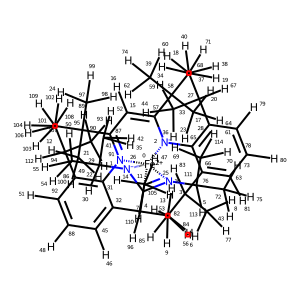

['Fe', 'N', 'N', 'C', 'H', 'C', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'N', 'N', 'C', 'C', 'C', 'H', 'C', 'C', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'C', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'C', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'C', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'C', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H']
smiles_2='[H]C1=C(C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])[N-](c2c(C([H])(C([H])([H])[H])C([H])([H])[H])c([H])c([H])c([H])c2C([H])(C([H])([H])[H])C([H])([H])[H])~[Fe+2]23(~N(c4c(C([H])(C([H])([H])[H])C([H])([H])[H])c([H])c([H])c([H])c4C([H])(C([H])([H])[H])C([H])([H])[H])=C1C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])~N(C([H])(C([H])([H])[H])C([H])([H])[H])=C~2([H])[N-]~3C([H])(C([H])([H])[H])C([H])([H])[H]'

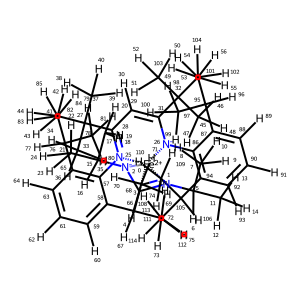

['Fe', 'N', 'N', 'C', 'H', 'C', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'N', 'N', 'C', 'C', 'C', 'H', 'C', 'C', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'C', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'C', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'C', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'C', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H']
smiles_2='[H]C1=C(C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])[N-](c2c(C([H])(C([H])([H])[H])C([H])([H])[H])c([H])c([H])c([H])c2C([H])(C([H])([H])[H])C([H])([H])[H])~[Fe+2]23(~N(c4c(C([H])(C([H])([H])[H])C([H])([H])[H])c([H])c([H])c([H])c4C([H])(C([H])([H])[H])C([H])([H])[H])=C1C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])~N(C([H])(C([H])([H])[H])C([H])([H])[H])=C~2([H])[N-]~3C([H])(C([H])([H])[H])C([H])([H])[H]'

In [14]:
for idx, mol in enumerate(cell.moleclist):
    if mol.iscomplex:
        smiles, obj = get_smiles_complex(mol, debug=1)
        print([atom.GetSymbol() for atom in obj.GetAtoms()])
        smiles_2 = Chem.MolToSmiles(obj)
        print(f"{smiles_2=}")
        print(smiles == smiles_2)
        # m = Chem.MolFromSmiles(smiles, sanitize=False)
        # display(m)